<a href="https://colab.research.google.com/github/cassiecinzori/ECON3916/blob/main/Project/ECON3916_Project_Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 | Phase 4: Model Execution & Reporting
### Cassandra Cinzori

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

###  STEP 4.0: Environment & Data

In [18]:
df = pd.read_csv('Mroz.csv')

df['city'] = df['city'].map({'yes': 1, 'no': 0})

# Subset to working women
df_work = df[df['work'] == 'yes'].copy()
df_nonwork = df[df['work'] == 'no'].copy()

# Feature engineering
df_work['log_hearnw'] = np.log(df_work['hearnw'])
df_work['exp2'] = df_work['experience'] ** 2

print(f"Full sample: {len(df)} | Working subsample: {len(df_work)} | Non-working: {len(df_nonwork)}")


Full sample: 753 | Working subsample: 428 | Non-working: 325


### STEP 4.1 - TABLE 1: Summary Statistics (Treated vs. Control)

In [19]:
vars_table1 = ['educw', 'experience', 'agew', 'child6', 'child618',
               'wageh', 'unemprate', 'city']

labels = {
    'educw':      'Education (years)',
    'experience': 'Experience (years)',
    'agew':       'Age',
    'child6':     'Children < 6',
    'child618':   'Children 6–18',
    'wageh':      "Husband's Wage ($)",
    'unemprate':  'County Unemployment Rate (%)',
    'city':       'Urban Residence (1=Yes)'
}

rows = []
for v in vars_table1:
    w_mean = df_work[v].mean()
    w_std  = df_work[v].std()
    n_mean = df_nonwork[v].mean()
    n_std  = df_nonwork[v].std()
    # t-test for difference in means
    t, p = stats.ttest_ind(df_work[v].dropna(), df_nonwork[v].dropna())
    rows.append({
        'Variable': labels[v],
        'Workers Mean': f"{w_mean:.3f}",
        'Workers SD':   f"({w_std:.3f})",
        'Non-Workers Mean': f"{n_mean:.3f}",
        'Non-Workers SD':   f"({n_std:.3f})",
        'p-value': f"{p:.3f}"
    })

table1 = pd.DataFrame(rows)
print("\n" + "="*80)
print("TABLE 1 — Summary Statistics: Working vs. Non-Working Women")
print("="*80)
print(table1.to_string(index=False))
print(f"\nN (Working): {len(df_work)}  |  N (Non-Working): {len(df_nonwork)}  |  N (Total): {len(df)}")
print("Note: Standard deviations in parentheses. p-values from two-sample t-tests.")




TABLE 1 — Summary Statistics: Working vs. Non-Working Women
                    Variable Workers Mean Workers SD Non-Workers Mean Non-Workers SD p-value
           Education (years)       12.659    (2.285)           11.797        (2.182)   0.000
          Experience (years)       13.037    (8.056)            7.462        (6.919)   0.000
                         Age       41.972    (7.721)           43.283        (8.468)   0.027
                Children < 6        0.140    (0.392)            0.366        (0.637)   0.000
               Children 6–18        1.350    (1.316)            1.357        (1.327)   0.947
          Husband's Wage ($)        7.226    (3.571)            7.819        (4.953)   0.057
County Unemployment Rate (%)        8.546    (3.033)            8.726        (3.221)   0.431
     Urban Residence (1=Yes)        0.640    (0.481)            0.646        (0.479)   0.866

N (Working): 428  |  N (Non-Working): 325  |  N (Total): 753
Note: Standard deviations in parentheses

### STEP 4.1 - Model Execution

In [20]:
model1 = smf.ols(
    'log_hearnw ~ educw + experience + exp2',
    data=df_work
).fit(cov_type='HC1')

# Model 2: Multivariate OLS (full controls)
model2 = smf.ols(
    'log_hearnw ~ educw + experience + exp2 + child6 + agew + unemprate + city',
    data=df_work
).fit(cov_type='HC1')

# Model 3: Interaction OLS (educw × city)
model3 = smf.ols(
    'log_hearnw ~ educw * city + experience + exp2 + child6 + agew + unemprate',
    data=df_work
).fit(cov_type='HC1')

print("\n" + "="*60)
print("MODEL 1 — Baseline OLS (HC1 Robust SEs)")
print("="*60)
print(model1.summary())

print("\n" + "="*60)
print("MODEL 2 — Multivariate OLS (HC1 Robust SEs)")
print("="*60)
print(model2.summary())

print("\n" + "="*60)
print("MODEL 3 — Interaction OLS: educw × city (HC1 Robust SEs)")
print("="*60)
print(model3.summary())



MODEL 1 — Baseline OLS (HC1 Robust SEs)
                            OLS Regression Results                            
Dep. Variable:             log_hearnw   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     27.30
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.68e-16
Time:                        02:03:43   Log-Likelihood:                -431.60
No. Observations:                 428   AIC:                             871.2
Df Residuals:                     424   BIC:                             887.4
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  

### STEP 4.1 - IV / 2SLS: Instruments = educwm + educwf

In [21]:
import subprocess
subprocess.run(['pip', 'install', 'linearmodels', '-q'], check=True)
from linearmodels.iv import IV2SLS

# Prepare matrices for linearmodels
df_iv = df_work[['log_hearnw', 'educw', 'experience', 'exp2',
                 'child6', 'agew', 'unemprate', 'city',
                 'educwm', 'educwf']].dropna().copy()

# Add constant
df_iv['const'] = 1.0

# First Stage: educw ~ instruments + controls
first_stage_formula = 'educw ~ experience + exp2 + child6 + agew + unemprate + city + educwm + educwf'
first_stage = smf.ols(first_stage_formula, data=df_iv).fit(cov_type='HC1')

print("\n" + "="*60)
print("FIRST STAGE — educw on instruments + controls")
print("="*60)
print(first_stage.summary())

# First Stage F-statistic (weak instrument test)
# F-stat on excluded instruments (educwm, educwf)
first_stage_restricted = smf.ols(
    'educw ~ experience + exp2 + child6 + agew + unemprate + city',
    data=df_iv
).fit()

n   = len(df_iv)
k   = len(first_stage.params)
r2_full = first_stage.rsquared
r2_rest = first_stage_restricted.rsquared
q   = 2  # number of excluded instruments

partial_F = ((r2_full - r2_rest) / q) / ((1 - r2_full) / (n - k))
print(f"\nPartial F-statistic on excluded instruments (educwm, educwf): {partial_F:.2f}")
print("Rule of thumb: F > 10 indicates instruments are not weak.")
if partial_F > 10:
    print("✓ Instruments pass the weak instrument test.")
else:
    print("⚠ Instruments may be weak — interpret IV estimates with caution.")

# IV/2SLS via manual two-stage
# Stage 1: fitted values of educw
df_iv['educw_hat'] = first_stage.fittedvalues

# Stage 2: replace educw with educw_hat
model_iv = smf.ols(
    'log_hearnw ~ educw_hat + experience + exp2 + child6 + agew + unemprate + city',
    data=df_iv
).fit(cov_type='HC1')

print("\n" + "="*60)
print("IV / 2SLS — Second Stage (HC1 Robust SEs)")
print("Instruments: educwm, educwf")
print("="*60)
print(model_iv.summary())
print("\nNote: SEs from manual 2SLS are illustrative. For publication,")
print("use linearmodels.IV2SLS for correctly adjusted standard errors.")




FIRST STAGE — educw on instruments + controls
                            OLS Regression Results                            
Dep. Variable:                  educw   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     17.36
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           2.25e-22
Time:                        02:03:53   Log-Likelihood:                -901.76
No. Observations:                 428   AIC:                             1822.
Df Residuals:                     419   BIC:                             1858.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

### STEP 4.2 - MODEL DIAGNOSTICS

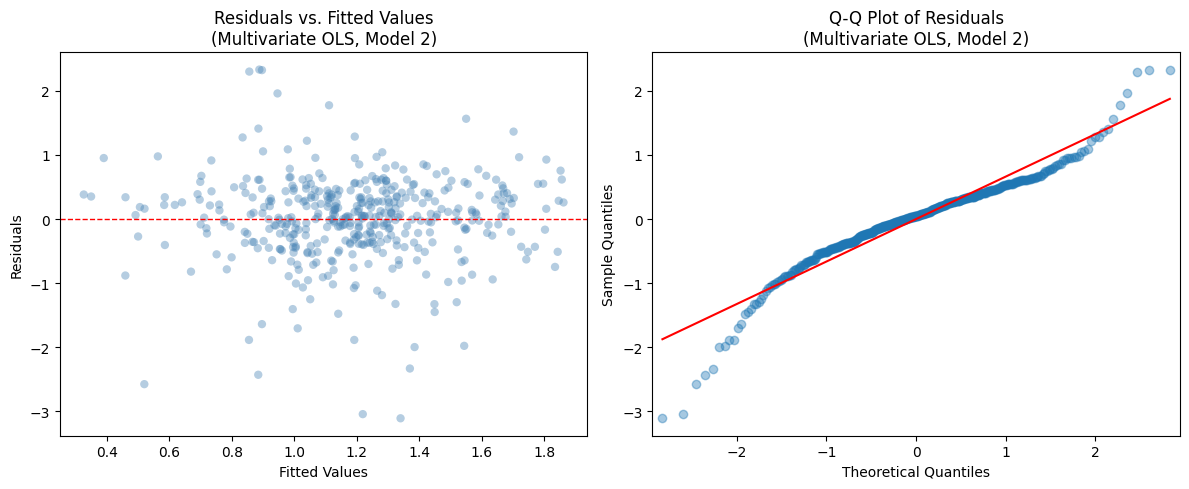

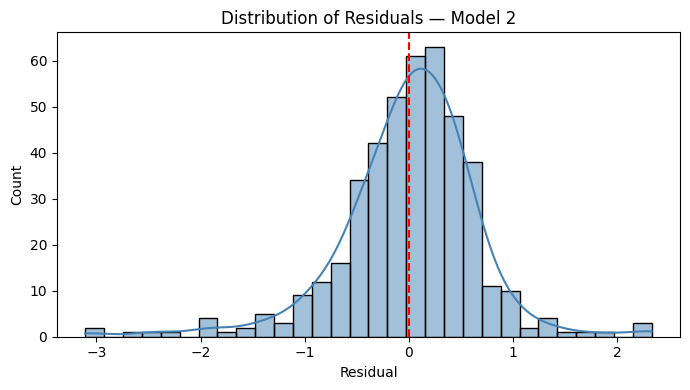


Residual Skewness: -0.7483  (|skew| < 0.5 → approximately symmetric)
Residual Kurtosis: 3.8170  (kurtosis ≈ 0 → approximately normal)

Breusch-Pagan Test:
  LM Statistic: 14.9336
  p-value:      0.0369
  → Reject H₀: Heteroscedasticity detected. HC1 robust SEs are justified.

ROBUSTNESS CHECK — Outliers Removed (n = 404)
  educw coefficient (full sample):    0.1074  (p=0.000)
  educw coefficient (trimmed sample): 0.0890  (p=0.000)
  → Coefficient stability: ✓ Stable


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

resid2   = model2.resid
fitted2  = model2.fittedvalues

axes[0].scatter(fitted2, resid2, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted Values\n(Multivariate OLS, Model 2)")

# 4.2b: Q-Q Plot (Normality of Residuals)
sm.qqplot(resid2, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title("Q-Q Plot of Residuals\n(Multivariate OLS, Model 2)")

plt.tight_layout()
plt.savefig("diagnostics_residuals.png", dpi=150)
plt.show()

# 4.2c: Residual Distribution
plt.figure(figsize=(7, 4))
sns.histplot(resid2, kde=True, color='steelblue', bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals — Model 2")
plt.xlabel("Residual")
plt.tight_layout()
plt.savefig("residual_distribution.png", dpi=150)
plt.show()

skew_val = stats.skew(resid2)
kurt_val = stats.kurtosis(resid2)
print(f"\nResidual Skewness: {skew_val:.4f}  (|skew| < 0.5 → approximately symmetric)")
print(f"Residual Kurtosis: {kurt_val:.4f}  (kurtosis ≈ 0 → approximately normal)")

# 4.2d: Breusch-Pagan Test for Heteroscedasticity
X_bp = model2.model.exog
bp_lm, bp_p, bp_fval, bp_fp = het_breuschpagan(resid2, X_bp)
print(f"\nBreusch-Pagan Test:")
print(f"  LM Statistic: {bp_lm:.4f}")
print(f"  p-value:      {bp_p:.4f}")
if bp_p < 0.05:
    print("  → Reject H₀: Heteroscedasticity detected. HC1 robust SEs are justified.")
else:
    print("  → Fail to reject H₀: No strong evidence of heteroscedasticity.")

# 4.2e: Robustness Check — Drop Outliers
Q1 = df_work['hearnw'].quantile(0.25)
Q3 = df_work['hearnw'].quantile(0.75)
IQR = Q3 - Q1
df_trimmed = df_work[(df_work['hearnw'] >= Q1 - 1.5*IQR) &
                     (df_work['hearnw'] <= Q3 + 1.5*IQR)].copy()
df_trimmed['log_hearnw'] = np.log(df_trimmed['hearnw'])
df_trimmed['exp2'] = df_trimmed['experience'] ** 2

model_robust_check = smf.ols(
    'log_hearnw ~ educw + experience + exp2 + child6 + agew + unemprate + city',
    data=df_trimmed
).fit(cov_type='HC1')

print(f"\n{'='*60}")
print(f"ROBUSTNESS CHECK — Outliers Removed (n = {len(df_trimmed)})")
print(f"{'='*60}")
print(f"  educw coefficient (full sample):    {model2.params['educw']:.4f}  (p={model2.pvalues['educw']:.3f})")
print(f"  educw coefficient (trimmed sample): {model_robust_check.params['educw']:.4f}  (p={model_robust_check.pvalues['educw']:.3f})")
print(f"  → Coefficient stability: {'✓ Stable' if abs(model2.params['educw'] - model_robust_check.params['educw']) < 0.02 else '⚠ Check stability'}")


### STEP 4.1 - TABLE 2: Professional Regression Table

In [23]:
models = {
    'Model 1\nBaseline OLS':      model1,
    'Model 2\nMultivariate OLS':  model2,
    'Model 3\nInteraction OLS':   model3,
    'Model 4\nIV/2SLS':           model_iv,
}

all_vars = ['educw', 'educw_hat', 'experience', 'exp2', 'child6',
            'agew', 'unemprate', 'city', 'city:educw', 'educw:city', 'Intercept']

print("\n" + "="*90)
print("TABLE 2 — Regression Results: Dependent Variable = log(hearnw)")
print("="*90)
header = f"{'Variable':<22}" + "".join([f"{k:>18}" for k in models.keys()])
print(header)
print("-"*90)

for v in all_vars:
    row = f"{v:<22}"
    for name, m in models.items():
        if v in m.params.index:
            coef = m.params[v]
            p    = m.pvalues[v]
            stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
            row += f"{coef:>12.4f}{stars:>6}"
        else:
            row += f"{'—':>18}"
    print(row)
    # Standard errors row
    se_row = f"{'':22}"
    for name, m in models.items():
        if v in m.bse.index:
            se_row += f"{'(' + f'{m.bse[v]:.4f}' + ')':>18}"
        else:
            se_row += f"{'':>18}"
    print(se_row)

print("-"*90)

obs_row   = f"{'Observations':<22}" + "".join([f"{int(m.nobs):>18}" for m in models.values()])
r2_row    = f"{'R²':<22}"           + "".join([f"{m.rsquared:>18.4f}" for m in models.values()])
adjr2_row = f"{'Adj. R²':<22}"      + "".join([f"{m.rsquared_adj:>18.4f}" for m in models.values()])
se_type   = f"{'Std. Errors':<22}"  + "".join([f"{'HC1 Robust':>18}" for _ in models])
print(obs_row)
print(r2_row)
print(adjr2_row)
print(se_type)
print("="*90)
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print("Standard errors in parentheses.")
print("Model 4 instruments: wife's mother's education (educwm), wife's father's education (educwf).")



TABLE 2 — Regression Results: Dependent Variable = log(hearnw)
Variable              Model 1
Baseline OLSModel 2
Multivariate OLSModel 3
Interaction OLS   Model 4
IV/2SLS
------------------------------------------------------------------------------------------
educw                       0.1075   ***      0.1074   ***      0.1068   ***                 —
                                (0.0132)          (0.0135)          (0.0178)                  
educw_hat                              —                 —                 —      0.0538      
                                                                                      (0.0361)
experience                  0.0416   ***      0.0406   ***      0.0406   ***      0.0433   ***
                                (0.0153)          (0.0152)          (0.0153)          (0.0163)
exp2                       -0.0008     *     -0.0008     *     -0.0008     *     -0.0009     *
                                (0.0004)          (0.0004)          (0.0